In [12]:
!pip install tensorflow pandas matplotlib scikit-learn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [13]:
#Load the dataset

df = pd.read_csv('CombinedData.csv')
df = df.dropna(subset=['statement', 'status']).copy()
x = df['statement'].astype(str)
y = df['status']

In [14]:
#endcode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y_encoded, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_encoded
    )

In [16]:
max_words = 10000
max_len = 64

tokenizer = Tokenizer(
num_words=max_words,
oov_token='<OOV>'
)
tokenizer.fit_on_texts(x_train)
    
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)
    
# Padding so every sample has the same sequence length
x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)
x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)


In [17]:
class LSTM_Model:
    def __init__(self, vocab_size, max_len, hidden_size, num_classes):
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.model = self.build_model()
            
    def build_model(self):
        model = Sequential([
            tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=128),
            Bidirectional(LSTM(self.hidden_size, dropout=0.3, recurrent_dropout=0.3)),
            Dense(64, activation="relu"),
            Dropout(0.4),
            
            
            Dense(num_classes, activation="softmax")
            ])
        model.compile(
            optimizer="adam", 
            loss="sparse_categorical_crossentropy", 
            metrics=["accuracy"]
            )
        return model

    def fit(self, x_train, y_train, epochs=10, batch_size=32, validation_split=0.3):
        early_stop= EarlyStopping(
            monitor='val_loss', 
            patience=3, 
            restore_best_weights=True)
        return self.model.fit(
            x_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split, 
            callbacks=[early_stop]
        )

    def predict(self, x_test):
        return self.model.predict(x_test)

In [18]:
lstm_model = LSTM_Model(
    vocab_size=vocab_size,
    max_len=max_len,
    hidden_size=30,
    num_classes=num_classes
)

history = lstm_model.fit(
    x_train_pad,
    y_train,
    epochs=10,
    batch_size=16,
    validation_split=0.3
)

Epoch 1/10
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.5867 - loss: 1.0156 - val_accuracy: 0.6522 - val_loss: 0.8142
Epoch 2/10
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 58s 36ms/step - accuracy: 0.7044 - loss: 0.7367 - val_accuracy: 0.7242 - val_loss: 0.6807
Epoch 3/10
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.7658 - loss: 0.5917 - val_accuracy: 0.7427 - val_loss: 0.6584
Epoch 4/10
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.8156 - loss: 0.4803 - val_accuracy: 0.7509 - val_loss: 0.6703
Epoch 5/10
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 58s 36ms/step - accuracy: 0.8542 - loss: 0.3938 - val_accuracy: 0.7453 - val_loss: 0.7069
Epoch 6/10
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.8842 - loss: 0.3148 - val_accuracy: 0.7474 - val_loss: 0.7843


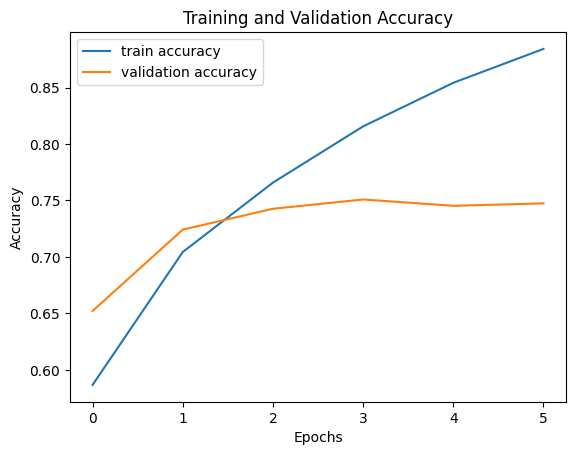

In [19]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [24]:
y_pred_probs = lstm_model.predict(x_test_pad)
y_pred = y_pred_probs.argmax(axis=1)

print("FINAL TEST RESULTS (LSTM)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
FINAL TEST RESULTS (LSTM)
Accuracy: 0.7321100917431193
Precision: 0.7332328931628894
Recall: 0.7321100917431193
F1 Score: 0.7278819593580935

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.72      0.81      0.76      1152
             Bipolar       0.64      0.71      0.67       833
          Depression       0.67      0.71      0.69      4622
              Normal       0.92      0.90      0.91      4903
Personality disorder       0.56      0.07      0.13       323
              Stress       0.45      0.53      0.49       776
            Suicidal       0.65      0.59      0.62      3196

            accuracy                           0.73     15805
           macro avg       0.66      0.62      0.61     15805
        weighted avg       0.73      0.73      0.73     15805



494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


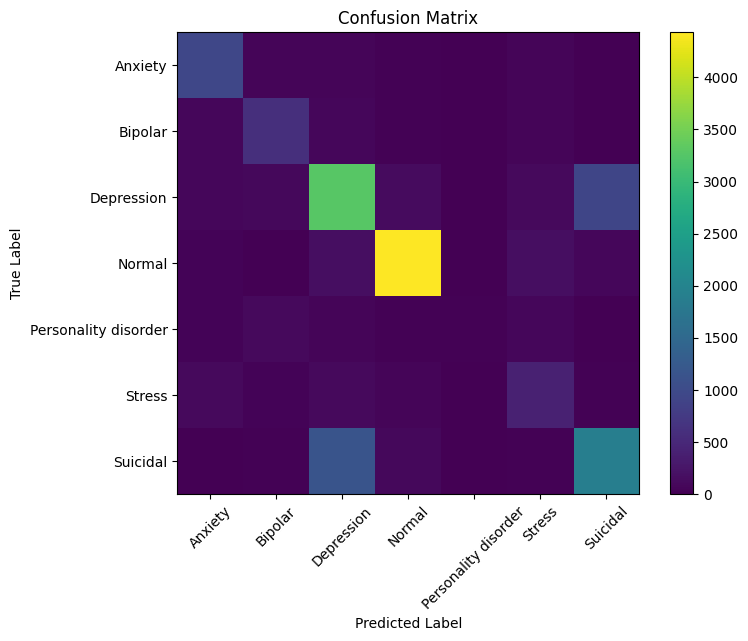

In [21]:
y_pred_probs = lstm_model.predict(x_test_pad)
y_pred = y_pred_probs.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = label_encoder.classes_
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()